In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# === paths (поменяй под свой мак) ===
PARQUET_PATH = Path("/Users/zhasik/Desktop/krisha/data/index/index.parquet")
PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")


In [2]:
df = pd.read_parquet(PARQUET_PATH)
print("shape:", df.shape)
df.head(3)


shape: (1885, 13)


,ad_id,url,price,area,price_per_m2,log_price_per_m2,rooms,district,building_type,year_built,floor,floors_total,image_paths
0,1002526087,https://krisha.kz/a/show/1002526087,56500000,75.1,7.523302e+05,13.530931,3,Алмалинский р-н,монолитный,2023,14,15,"[data/images/1002526087/01.jpg, data/images/10..."
1,1005774259,https://krisha.kz/a/show/1005774259,130000000,95.0,1.368421e+06,14.129168,3,Алмалинский р-н,монолитный,2024,17,17,"[data/images/1005774259/01.jpg, data/images/10..."
2,1000941933,https://krisha.kz/a/show/1000941933,50000000,56.5,8.849558e+05,13.693293,2,Наурызбайский р-н,монолитный,2024,3,4,"[data/images/1000941933/01.jpg, data/images/10..."


In [3]:
import json

def ensure_list(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass
        return [p.strip().strip('"').strip("'") for p in s.split(",") if p.strip()]
    return []

df["image_paths_list"] = df["image_paths"].apply(ensure_list)
df["n_images"] = df["image_paths_list"].apply(len)

df[["ad_id","n_images"]].head()


,ad_id,n_images
0,1002526087,7
1,1005774259,7
2,1000941933,7
3,1007626840,6
4,1007794206,5


In [4]:
CURRENT_YEAR = 2025

df_feat = df.copy()

# derived
df_feat["floor_ratio"] = df_feat["floor"] / df_feat["floors_total"]
df_feat["is_first"] = (df_feat["floor"] == 1).astype(int)
df_feat["is_last"]  = (df_feat["floor"] == df_feat["floors_total"]).astype(int)
df_feat["building_age"] = CURRENT_YEAR - df_feat["year_built"]

# safety clips (на всякий)
df_feat["floor_ratio"] = df_feat["floor_ratio"].clip(0, 1)

TARGET = "log_price_per_m2"

FEATURES_NUM = [
    "area",
    "rooms",
    "floor",
    "floors_total",
    "floor_ratio",
    "is_first",
    "is_last",
    "building_age",
]

FEATURES_CAT = ["district", "building_type"]

FEATURES = FEATURES_NUM + FEATURES_CAT

# quick check
df_feat[FEATURES + [TARGET]].isna().mean().sort_values(ascending=False).head(20)


area                0.0
rooms               0.0
floor               0.0
floors_total        0.0
floor_ratio         0.0
is_first            0.0
is_last             0.0
building_age        0.0
district            0.0
building_type       0.0
log_price_per_m2    0.0
dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

X = df_feat[FEATURES]
y = df_feat[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=df_feat["district"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=X_temp["district"]
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1319, 10) Val: (283, 10) Test: (283, 10)


In [7]:
from catboost import CatBoostRegressor

cat_features_idx = [X.columns.get_loc(c) for c in FEATURES_CAT]

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_features_idx
)


0:	learn: 0.2957807	test: 0.3002782	best: 0.3002782 (0)	total: 59.2ms	remaining: 2m 57s
200:	learn: 0.1756842	test: 0.2033459	best: 0.2033459 (200)	total: 438ms	remaining: 6.1s
400:	learn: 0.1440608	test: 0.1974866	best: 0.1973797 (393)	total: 810ms	remaining: 5.25s
600:	learn: 0.1243229	test: 0.1947497	best: 0.1946813 (599)	total: 1.24s	remaining: 4.95s
800:	learn: 0.1096967	test: 0.1936729	best: 0.1936230 (770)	total: 1.54s	remaining: 4.23s
1000:	learn: 0.0985907	test: 0.1932718	best: 0.1931302 (969)	total: 1.78s	remaining: 3.56s
1200:	learn: 0.0886857	test: 0.1930693	best: 0.1929261 (1141)	total: 2.04s	remaining: 3.06s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.192926117
bestIteration = 1141

Shrink model to first 1142 iterations.


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

def eval_block(model, X, y, name):
    pred_log = model.predict(X)

    r2 = r2_score(y, pred_log)

    ppm2_true = np.exp(y)
    ppm2_pred = np.exp(pred_log)
    mae_ppm2 = mean_absolute_error(ppm2_true, ppm2_pred)

    print(f"\n{name}")
    print(f"R2 (log_price_per_m2): {r2:.4f}")
    print(f"MAE (price_per_m2): {mae_ppm2:,.0f} ₸/м²")
    return r2, mae_ppm2

r2_tr, mae_tr = eval_block(model, X_train, y_train, "Train")
r2_va, mae_va = eval_block(model, X_val, y_val, "Val")
r2_te, mae_te = eval_block(model, X_test, y_test, "Test")



Train
R2 (log_price_per_m2): 0.8799
MAE (price_per_m2): 64,923 ₸/м²

Val
R2 (log_price_per_m2): 0.5964
MAE (price_per_m2): 118,765 ₸/м²

Test
R2 (log_price_per_m2): 0.5928
MAE (price_per_m2): 114,077 ₸/м²


In [9]:
def price_mae(model, X, y, name):
    pred_log = model.predict(X)
    ppm2_pred = np.exp(pred_log)
    ppm2_true = np.exp(y)

    price_pred = ppm2_pred * X["area"].astype(float).values
    price_true = ppm2_true * X["area"].astype(float).values

    mae_price = mean_absolute_error(price_true, price_pred)
    print(f"{name} MAE(price): {mae_price:,.0f} ₸")
    return mae_price

mae_price_test = price_mae(model, X_test, y_test, "Test")


Test MAE(price): 10,176,110 ₸


,feature,importance
8,district,30.622833
7,building_age,18.030441
0,area,14.979811
3,floors_total,12.887425
4,floor_ratio,5.861945
2,floor,5.713942
9,building_type,5.531596
1,rooms,4.212088
6,is_last,1.749750
5,is_first,0.410169


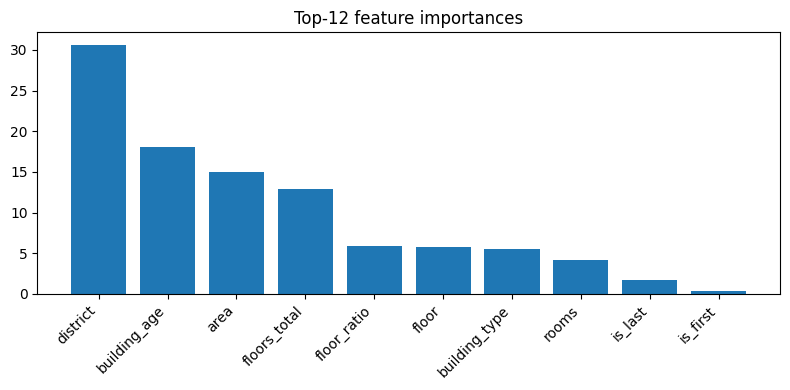

In [10]:
fi = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(fi)

plt.figure(figsize=(8,4))
plt.bar(fi["feature"][:12], fi["importance"][:12])
plt.xticks(rotation=45, ha="right")
plt.title("Top-12 feature importances")
plt.tight_layout()
plt.show()


In [11]:
from pathlib import Path

OUT_DIR = PROJECT_ROOT / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUT_DIR / "catboost_tabular_baseline.cbm"
model.save_model(str(model_path))
print("Saved:", model_path)

# сохраним ad_id для test set (чтобы потом делать сравнения 1-в-1)
splits_dir = PROJECT_ROOT / "data" / "processed"
splits_dir.mkdir(parents=True, exist_ok=True)

pd.Series(df_feat.loc[X_train.index, "ad_id"].astype(str).values).to_csv(splits_dir / "train_ad_ids.csv", index=False)
pd.Series(df_feat.loc[X_val.index, "ad_id"].astype(str).values).to_csv(splits_dir / "val_ad_ids.csv", index=False)
pd.Series(df_feat.loc[X_test.index, "ad_id"].astype(str).values).to_csv(splits_dir / "test_ad_ids.csv", index=False)

print("Saved splits to:", splits_dir)


Saved: /Users/zhasik/Desktop/krisha/models/catboost_tabular_baseline.cbm
Saved splits to: /Users/zhasik/Desktop/krisha/data/processed


In [12]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")

print((PROJECT_ROOT / "models" / "catboost_tabular_baseline.cbm").exists())
print((PROJECT_ROOT / "data" / "processed" / "train_ad_ids.csv").exists())
print((PROJECT_ROOT / "data" / "processed" / "val_ad_ids.csv").exists())
print((PROJECT_ROOT / "data" / "processed" / "test_ad_ids.csv").exists())


True
True
True
True


In [13]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")
OUT = PROJECT_ROOT / "models"
OUT.mkdir(parents=True, exist_ok=True)

CURRENT_YEAR = 2025
TARGET = "log_price_per_m2"
FEATURES_NUM = ["area","rooms","floor","floors_total","floor_ratio","is_first","is_last","building_age"]
FEATURES_CAT = ["district","building_type"]
FEATURES = FEATURES_NUM + FEATURES_CAT

v1_meta = {
    "version": "v1_tabular_baseline",
    "target": TARGET,
    "current_year": CURRENT_YEAR,
    "features_num": FEATURES_NUM,
    "features_cat": FEATURES_CAT,
    "features": FEATURES,
    "split_seed": 42,
    # можешь руками вписать твои финальные метрики:
    "metrics_test": {
        "r2_log": 0.5928,
        "mae_ppm2": 114077,
        "mae_price": 10176110
    }
}

meta_path = OUT / "v1_metadata.json"
meta_path.write_text(json.dumps(v1_meta, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", meta_path)


Saved: /Users/zhasik/Desktop/krisha/models/v1_metadata.json


In [14]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from catboost import CatBoostRegressor

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")

model_path = PROJECT_ROOT / "models" / "catboost_tabular_baseline.cbm"
meta = json.loads((PROJECT_ROOT / "models" / "v1_metadata.json").read_text(encoding="utf-8"))

model = CatBoostRegressor()
model.load_model(str(model_path))

def make_features_one(x: dict) -> pd.DataFrame:
    # ожидаем сырые поля
    area = float(x["area"])
    rooms = int(x["rooms"])
    floor = int(x["floor"])
    floors_total = int(x["floors_total"])
    year_built = int(x["year_built"])
    district = str(x["district"])
    building_type = str(x["building_type"])

    floor_ratio = min(max(floor / floors_total, 0.0), 1.0)
    is_first = int(floor == 1)
    is_last = int(floor == floors_total)
    building_age = meta["current_year"] - year_built

    row = {
        "area": area,
        "rooms": rooms,
        "floor": floor,
        "floors_total": floors_total,
        "floor_ratio": floor_ratio,
        "is_first": is_first,
        "is_last": is_last,
        "building_age": building_age,
        "district": district,
        "building_type": building_type,
    }
    return pd.DataFrame([row], columns=meta["features"])

def predict_price(x: dict):
    X1 = make_features_one(x)
    pred_log = float(model.predict(X1))
    ppm2 = float(np.exp(pred_log))
    price = ppm2 * float(x["area"])
    return {"price": price, "price_per_m2": ppm2, "pred_log_ppm2": pred_log}

# пример вызова
predict_price({
    "area": 75.1,
    "rooms": 3,
    "floor": 14,
    "floors_total": 15,
    "year_built": 2023,
    "district": "Алмалинский р-н",
    "building_type": "монолитный"
})


/var/folders/ns/k49cn2y90z511xzg2m9mxjf40000gn/T/ipykernel_5900/3770476738.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_log = float(model.predict(X1))


{'price': 62226861.852926955,
 'price_per_m2': 828586.709093568,
 'pred_log_ppm2': 13.627476768300761}